# Water Temperature by Monitoring Station

This notebook creates a visualization of the monitoring stations with the highest average recorded water temperature in the San Francisco Inner Bay water quality database.

The analysis uses a DuckDB relational database created from Water Quality Portal data. The query joins the `station`, `activity`, `result`, and `characteristic` tables to identify records where the measured characteristic is `Temperature, water`. For each station, the notebook calculates the average recorded water temperature and the number of temperature records available.

Only stations with at least five temperature measurements are included. This helps avoid ranking stations based on very small sample sizes. The final visualization displays the top 10 stations by average recorded water temperature, with each bar labeled by the average temperature in degrees Celsius and the number of records used in the calculation.

## Workflow

1. Connect to the DuckDB database.
2. Query water temperature results by station.
3. Calculate average temperature and record count for each station.
4. Filter to stations with at least five temperature records.
5. Plot the top 10 stations using a horizontal bar chart.

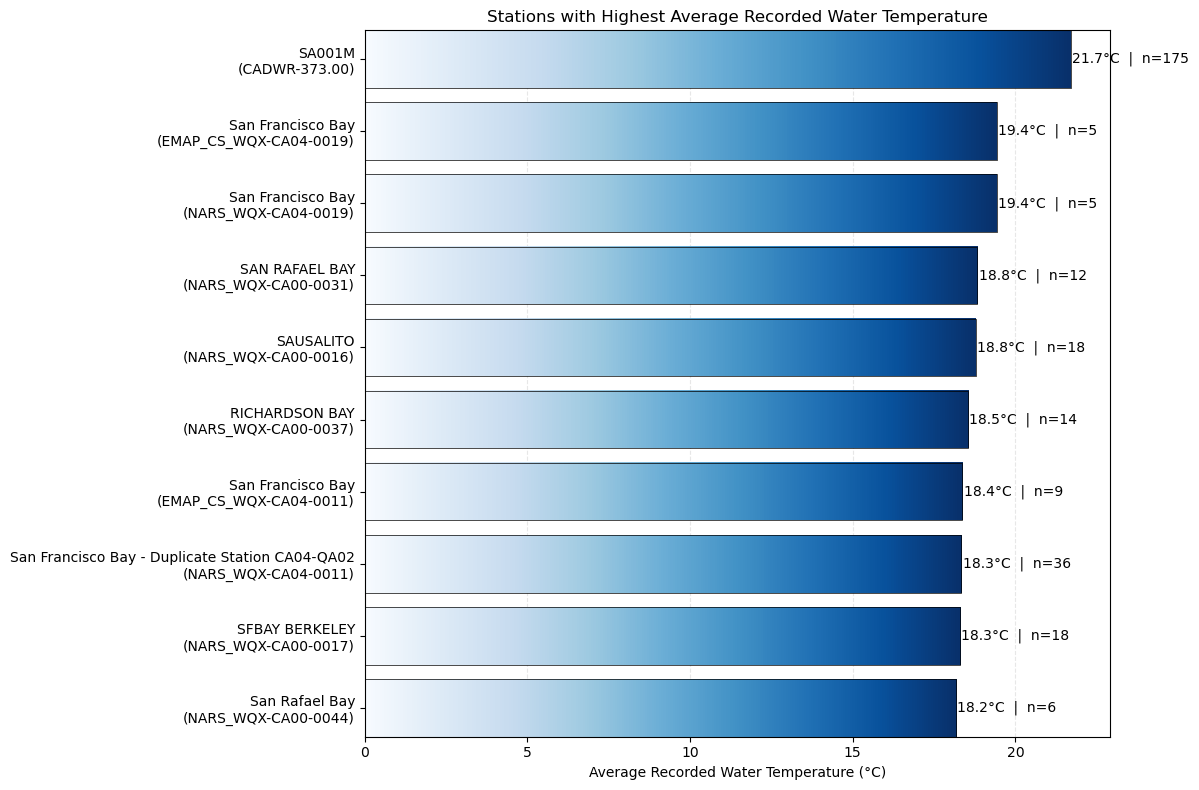

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Connect to DuckDB database
conn = duckdb.connect("database/database.duckdb")

# Query average water temperature by station
query = """
SELECT 
    s.station_id,
    s.station_name,
    r.result_unit,
    COUNT(r.result_pk) AS num_temp_results,
    AVG(r.result_value) AS avg_water_temp
FROM station AS s
JOIN activity AS a
    ON s.station_id = a.station_id
JOIN result AS r
    ON a.activity_pk = r.activity_pk
JOIN characteristic AS c
    ON r.characteristic_id = c.characteristic_id
WHERE c.characteristic_name = 'Temperature, water'
  AND r.result_value IS NOT NULL
GROUP BY 
    s.station_id,
    s.station_name,
    r.result_unit
HAVING COUNT(r.result_pk) >= 5
ORDER BY avg_water_temp DESC
LIMIT 10;
"""

temp_by_station = conn.execute(query).df()

# Create station label for y-axis
temp_by_station["station_label"] = (
    temp_by_station["station_name"] + "\n(" + temp_by_station["station_id"] + ")"
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

y_positions = np.arange(len(temp_by_station))

# Create gradient bars
for i, row in temp_by_station.iterrows():
    gradient = np.linspace(0.15, 1, 256).reshape(1, -1)

    ax.imshow(
        gradient,
        aspect="auto",
        cmap="Blues",
        extent=[0, row["avg_water_temp"], i - 0.4, i + 0.4],
        zorder=2
    )

    # Bar outline
    ax.barh(
        i,
        row["avg_water_temp"],
        height=0.8,
        color="none",
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    # Text label at end of bar
    ax.text(
        row["avg_water_temp"] + 0.05,
        i,
        f"{row['avg_water_temp']:.1f}°C  |  n={row['num_temp_results']}",
        va="center",
        fontsize=10
    )

# Axis formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(temp_by_station["station_label"])
ax.invert_yaxis()

ax.set_xlabel("Average Recorded Water Temperature (°C)")
ax.set_ylabel("")
ax.set_title("Stations with Highest Average Recorded Water Temperature")

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_xlim(0, temp_by_station["avg_water_temp"].max() + 1.2)

plt.tight_layout()
plt.show()

conn.close()